# Лабораторная 8. Автоэнкодеры

**Задание.** Реализовать автоэнкодеры: а) автоэнкодер с полносвязными слоями;
б) вариационный автоэнкодер.

Для обеих моделей, используя выборки MNIST и FashionMNIST:

1) реализовать различные варианты зашумления и исследовать, как зависит качество
нормализации изображения (очистки от шума): а) от типа зашумления (равномерный
шум, нормальный шум, локальная порча изображений); б) от размерности пространства
скрытых признаков; в) от количества и ширины слоёв кодера и декодера; а также от
гиперпараметров: г) количества эпох; д) коэффициента обучения;

2) оценить качество изображений, восстановленных из чистых и зашумлённых
изображений;

3) оценить возможность генерирования новых изображений из случайных точек в
латентном пространстве (пространстве скрытых признаков).

## 1. Теория

### Данные

MNIST и FashionMNIST: изображения $28 \times 28$ в градациях серого, 10 классов.
Из каждой выборки берётся 8000 обучающих и 1000 тестовых изображений, яркости
делятся на 255. Изображение разворачивается в вектор длины 784.

### Автоэнкодер

Автоэнкодер состоит из кодера $f$ и декодера $g$ и обучается восстанавливать
собственный вход:

$$z = f(x), \qquad \hat x = g(z), \qquad L = \lVert x - \hat x\rVert^2 .$$

Размерность $z$ меньше размерности $x$, поэтому сеть вынуждена сжать изображение
до $d$ чисел так, чтобы по ним его можно было восстановить.

### Очистка от шума

Шумоподавляющий автоэнкодер обучается на парах «зашумлённое изображение на
входе, чистое на выходе»:

$$L = \lVert x - g(f(\tilde x))\rVert^2, \qquad \tilde x = \text{шум}(x).$$

Виды зашумления: равномерный шум (добавка $\mathrm{U}[-\ell, \ell]$ к каждому
пикселю), нормальный шум (добавка $\mathrm{N}(0, \ell^2)$), локальная порча
(два квадратных пятна случайного положения со стороной $28\ell$).

### Вариационный автоэнкодер

Кодер выдаёт не точку, а параметры распределения $\mu(x)$ и $\log\sigma^2(x)$;
код берётся как $z = \mu + \sigma\varepsilon$ при
$\varepsilon \sim \mathcal{N}(0, I)$ (репараметризация, благодаря которой
градиент проходит через выборку). Функция потерь

$$L = \underbrace{\lVert x - \hat x\rVert^2}_{\text{восстановление}}
    + \beta\underbrace{\left(-\tfrac12\sum_{j}\bigl(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\bigr)\right)}_{\text{KL-дивергенция}} .$$

Второе слагаемое стягивает распределение кодов к $\mathcal{N}(0, I)$, поэтому
точка, взятая из $\mathcal{N}(0, I)$, декодируется в правдоподобное изображение.

### Меры качества

$$\mathrm{MSE} = \frac{1}{n}\sum_k (x_k - \hat x_k)^2 .$$

SSIM (structural similarity) сравнивает локальные яркость, контраст и структуру
и лучше согласуется со зрительной оценкой; значение 1 означает совпадение.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| размерность латента | 2, 4, 8, 16, 32, 64 |
| тип шума | равномерный, нормальный, пятна |
| уровень шума | $0.2$, $0.4$ |
| слои кодера | $(128)$, $(256)$, $(512, 256)$, $(512, 256, 128)$ |
| число эпох | 10, 20, 40 |
| коэффициент обучения | $3\cdot10^{-4}$, $10^{-3}$, $3\cdot10^{-3}$ |

## 2. Данные и модели шума

In [1]:
import os
import struct
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity

torch.manual_seed(20260905)
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, устройство: {DEVICE}')

torch 2.11.0+cu128, устройство: cuda


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def find_dir(name, env):
    for c in [os.environ.get(env), f'../data/{name}/raw', f'data/{name}/raw',
              '../../bachelor/Perceptron/data_generation/MNIST/raw' if name == 'MNIST' else None]:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError(name)


def load(name, env, n_train, n_test, rng):
    D = find_dir(name, env)
    Xtr = read_idx(D / 'train-images-idx3-ubyte')
    Xte = read_idx(D / 't10k-images-idx3-ubyte')
    yte = read_idx(D / 't10k-labels-idx1-ubyte')
    itr = rng.choice(len(Xtr), n_train, replace=False)
    ite = rng.choice(len(Xte), n_test, replace=False)
    return (Xtr[itr].astype(np.float32) / 255.0,
            Xte[ite].astype(np.float32) / 255.0, yte[ite])


DATA = {
    'MNIST': load('MNIST', 'MNIST_DIR', 8000, 1000, np.random.default_rng(20260905)),
    'FashionMNIST': load('FashionMNIST', 'FASHION_DIR', 8000, 1000,
                         np.random.default_rng(20260905)),
}
for k, (a, b, _) in DATA.items():
    print(f'{k}: обучающая {a.shape}, тестовая {b.shape}')

MNIST: обучающая (8000, 28, 28), тестовая (1000, 28, 28)
FashionMNIST: обучающая (8000, 28, 28), тестовая (1000, 28, 28)


In [3]:
def noise_uniform(X, level, rng):
    """Равномерный шум: добавка U[-level, level] к каждому пикселю."""
    return np.clip(X + rng.uniform(-level, level, X.shape), 0, 1).astype(np.float32)


def noise_normal(X, level, rng):
    """Нормальный шум с sigma = level."""
    return np.clip(X + rng.normal(0, level, X.shape), 0, 1).astype(np.float32)


def noise_blot(X, level, rng):
    """Локальная порча: квадратные пятна случайного положения."""
    X = X.copy()
    size = max(4, int(round(28 * level)))
    n_blots = 2
    for i in range(len(X)):
        for _ in range(n_blots):
            r0 = rng.integers(0, 28 - size + 1)
            c0 = rng.integers(0, 28 - size + 1)
            X[i, r0:r0 + size, c0:c0 + size] = rng.random((size, size))
    return X.astype(np.float32)


NOISES = {'равномерный': noise_uniform, 'нормальный': noise_normal,
          'пятна': noise_blot}

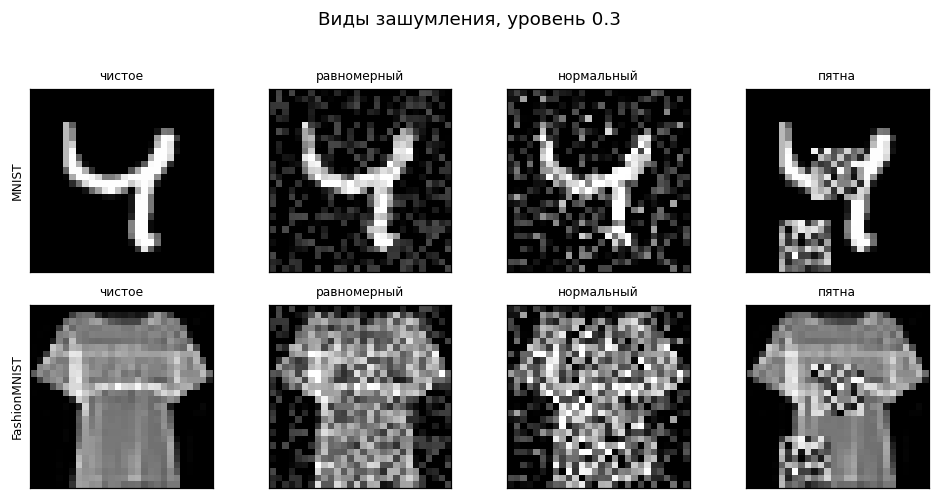

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(9, 4.4))
for row, ds in enumerate(['MNIST', 'FashionMNIST']):
    X = DATA[ds][1]
    axes[row, 0].imshow(X[0], cmap='gray'); axes[row, 0].set_title('чистое', fontsize=8)
    for col, (name, f) in enumerate(NOISES.items(), start=1):
        axes[row, col].imshow(f(X[:1], 0.3, np.random.default_rng(1))[0], cmap='gray')
        axes[row, col].set_title(name, fontsize=8)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(ds, fontsize=8)
fig.suptitle('Виды зашумления, уровень 0.3', y=1.02)
plt.tight_layout()
plt.show()

## 3. Автоэнкодер и вариационный автоэнкодер

In [5]:
def dense_stack(dims):
    """Полносвязные слои с ReLU между ними по размерам dims."""
    layers = []
    for a, b in zip(dims[:-1], dims[1:]):
        layers += [nn.Linear(a, b), nn.ReLU()]
    return layers


class AE(nn.Module):
    """Автоэнкодер с полносвязными слоями."""

    def __init__(self, latent=16, hidden=(256,)):
        super().__init__()
        self.latent = latent
        hidden = list(hidden)
        # кодер сужает 784 до latent, декодер разворачивает обратно теми же ширинами
        self.encoder = nn.Sequential(*dense_stack([784] + hidden),
                                     nn.Linear(hidden[-1], latent))
        self.decoder = nn.Sequential(*dense_stack([latent] + hidden[::-1]),
                                     nn.Linear(hidden[0], 784), nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x)), None

    def sample(self, n):
        """Декодирование n случайных точек латентного пространства."""
        device = next(self.parameters()).device  # где лежат веса, там и считаем
        return self.decoder(torch.randn(n, self.latent, device=device))


class VAE(nn.Module):
    """Вариационный автоэнкодер."""

    def __init__(self, latent=16, hidden=(256,)):
        super().__init__()
        self.latent = latent
        hidden = list(hidden)
        self.encoder = nn.Sequential(*dense_stack([784] + hidden))
        self.mu = nn.Linear(hidden[-1], latent)          # среднее распределения кодов
        self.logvar = nn.Linear(hidden[-1], latent)      # логарифм дисперсии
        self.decoder = nn.Sequential(*dense_stack([latent] + hidden[::-1]),
                                     nn.Linear(hidden[0], 784), nn.Sigmoid())

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
        # репараметризация: z = mu + sigma * eps, случайность вынесена в eps
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decoder(z), (mu, logvar)

    def sample(self, n):
        device = next(self.parameters()).device
        return self.decoder(torch.randn(n, self.latent, device=device))

In [6]:
def train_ae(model, Xn, Xc, epochs=20, lr=1e-3, batch=128, beta=1.0, seed=0):
    """Xn это вход (возможно зашумлённый), Xc это цель (чистое изображение)."""
    torch.manual_seed(seed)
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    xn = torch.tensor(Xn.reshape(len(Xn), -1)).to(DEVICE)  # каждое изображение в строку
    xc = torch.tensor(Xc.reshape(len(Xc), -1)).to(DEVICE)
    hist, t0 = [], time.time()
    for _ in range(epochs):
        perm = torch.randperm(len(xn), device=DEVICE)
        tot = 0.0
        for s in range(0, len(xn), batch):
            b = perm[s:s + batch]
            out, extra = model(xn[b])
            loss = ((out - xc[b]) ** 2).sum(1).mean()
            if extra is not None:  # у VAE добавляется KL-слагаемое
                mu, logvar = extra
                kl = -0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(1).mean()
                loss = loss + beta * kl
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(b)
        hist.append(tot / len(xn))
    return np.array(hist), time.time() - t0


def reconstruct(model, X):
    """Прогон изображений через сеть и обратно в форму (N, 28, 28)."""
    model.eval()
    with torch.no_grad():
        out, _ = model(torch.tensor(X.reshape(len(X), -1)).to(DEVICE))
    return out.cpu().numpy().reshape(-1, 28, 28)


def quality(ref, rec):
    """MSE по пикселям и средний SSIM по изображениям."""
    mse = float(np.mean((ref - rec) ** 2))
    ssim = float(np.mean([structural_similarity(a, b, data_range=1.0)
                          for a, b in zip(ref, rec)]))
    return mse, ssim

## 4. Размерность латентного пространства

In [7]:
EPOCHS = 20
LEVEL = 0.3
Xtr, Xte, yte = DATA['MNIST']
rng = np.random.default_rng(20260905)
Xtr_n = noise_normal(Xtr, LEVEL, rng)
Xte_n = noise_normal(Xte, LEVEL, np.random.default_rng(1))

rows = []
t0 = time.time()
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for latent in [2, 4, 8, 16, 32, 64]:
        torch.manual_seed(20260905)
        model = cls(latent=latent, hidden=(256,))
        hist, dt = train_ae(model, Xtr_n, Xtr, epochs=EPOCHS, lr=1e-3)
        rec_noisy = reconstruct(model, Xte_n)
        rec_clean = reconstruct(model, Xte)
        mse_n, ssim_n = quality(Xte, rec_noisy)
        mse_c, ssim_c = quality(Xte, rec_clean)
        rows.append(dict(stage='латент', dataset='MNIST', model=cls_name,
                         latent=latent, hidden='(256,)', noise='нормальный',
                         level=LEVEL, epochs=EPOCHS, lr=1e-3,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
lat = pd.DataFrame(rows)
print(f'{len(lat)} конфигураций за {time.time() - t0:.0f} с')
lat.pivot_table(index='latent', columns='model',
                values=['mse_noisy', 'ssim_noisy']).round(4)

12 конфигураций за 26 с


mse_noisy         ssim_noisy        
model         AE     VAE         AE     VAE
latent                                     
2         0.0485  0.0500     0.4322  0.4024
4         0.0372  0.0406     0.5729  0.5191
8         0.0272  0.0338     0.6902  0.5838
16        0.0200  0.0333     0.7608  0.5813
32        0.0161  0.0346     0.7954  0.5750
64        0.0153  0.0362     0.8070  0.5516

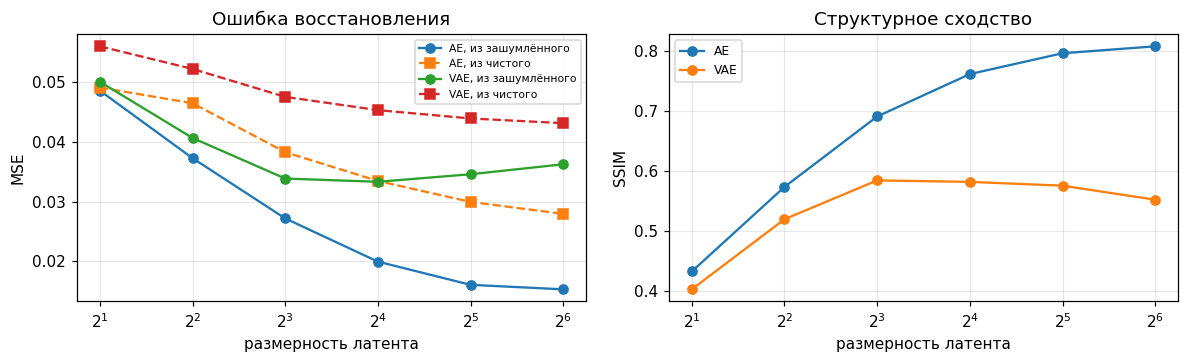

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for m in ['AE', 'VAE']:
    s = lat[lat.model == m].sort_values('latent')
    axes[0].plot(s.latent, s.mse_noisy, marker='o', label=f'{m}, из зашумлённого')
    axes[0].plot(s.latent, s.mse_clean, marker='s', ls='--', label=f'{m}, из чистого')
    axes[1].plot(s.latent, s.ssim_noisy, marker='o', label=m)
axes[0].set_xscale('log', base=2); axes[0].set_xlabel('размерность латента')
axes[0].set_ylabel('MSE'); axes[0].set_title('Ошибка восстановления')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7)
axes[1].set_xscale('log', base=2); axes[1].set_xlabel('размерность латента')
axes[1].set_ylabel('SSIM'); axes[1].set_title('Структурное сходство')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Тип и уровень зашумления

In [9]:
LATENT = int(lat[lat.model == 'AE'].sort_values('mse_noisy').iloc[0]['latent'])
print(f'выбрана размерность латента {LATENT}')

rows = []
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for nname, nf in NOISES.items():
        for level in [0.2, 0.4]:
            rng = np.random.default_rng(20260905)
            Xn_tr = nf(Xtr, level, rng)
            Xn_te = nf(Xte, level, np.random.default_rng(1))
            torch.manual_seed(20260905)
            model = cls(latent=LATENT, hidden=(256,))
            hist, dt = train_ae(model, Xn_tr, Xtr, epochs=EPOCHS, lr=1e-3)
            mse_n, ssim_n = quality(Xte, reconstruct(model, Xn_te))
            mse_c, ssim_c = quality(Xte, reconstruct(model, Xte))
            mse_in, ssim_in = quality(Xte, Xn_te)  # качество самого зашумлённого входа
            rows.append(dict(stage='шум', dataset='MNIST', model=cls_name,
                             latent=LATENT, hidden='(256,)', noise=nname,
                             level=level, epochs=EPOCHS, lr=1e-3,
                             mse_noisy=mse_n, ssim_noisy=ssim_n,
                             mse_clean=mse_c, ssim_clean=ssim_c,
                             mse_input=mse_in, ssim_input=ssim_in,
                             params=sum(p.numel() for p in model.parameters()),
                             time=round(dt, 1)))
noi = pd.DataFrame(rows)
noi['выигрыш SSIM'] = (noi.ssim_noisy - noi.ssim_input).round(4)
print(noi[['model', 'noise', 'level', 'ssim_input', 'ssim_noisy', 'выигрыш SSIM',
           'mse_input', 'mse_noisy']].round(4).to_string(index=False))

выбрана размерность латента 64


model       noise  level  ssim_input  ssim_noisy  выигрыш SSIM  mse_input  mse_noisy
   AE равномерный    0.2      0.6839      0.8628        0.1789     0.0072     0.0110
   AE равномерный    0.4      0.5852      0.8283        0.2432     0.0283     0.0135
   AE  нормальный    0.2      0.6169      0.8420        0.2251     0.0211     0.0124
   AE  нормальный    0.4      0.4499      0.7742        0.3243     0.0794     0.0182
   AE       пятна    0.2      0.8105      0.7914       -0.0190     0.0274     0.0167
   AE       пятна    0.4      0.5365      0.5941        0.0576     0.0822     0.0353
  VAE равномерный    0.2      0.6839      0.5827       -0.1012     0.0072     0.0329
  VAE равномерный    0.4      0.5852      0.5537       -0.0315     0.0283     0.0356
  VAE  нормальный    0.2      0.6169      0.5703       -0.0466     0.0211     0.0346
  VAE  нормальный    0.4      0.4499      0.5220        0.0721     0.0794     0.0390
  VAE       пятна    0.2      0.8105      0.5270       -0.2834   

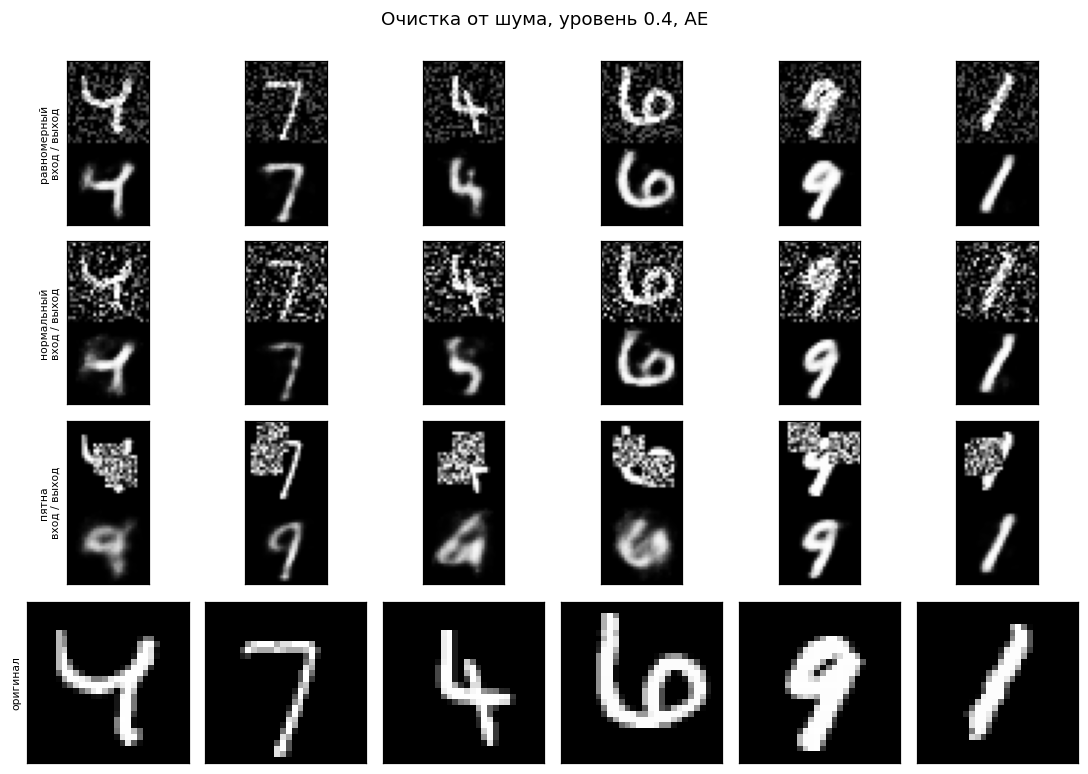

In [10]:
fig, axes = plt.subplots(4, 6, figsize=(10, 7))
for row, (nname, nf) in enumerate(list(NOISES.items())):
    Xn_tr = nf(Xtr, 0.4, np.random.default_rng(20260905))
    Xn_te = nf(Xte, 0.4, np.random.default_rng(1))
    torch.manual_seed(20260905)
    model = AE(latent=LATENT, hidden=(256,))
    train_ae(model, Xn_tr, Xtr, epochs=EPOCHS, lr=1e-3)
    rec = reconstruct(model, Xn_te)
    for col in range(6):
        # vstack ставит вход над выходом, получается две строки в одной картинке
        axes[row, col].imshow(np.vstack([Xn_te[col], rec[col]]), cmap='gray')
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f'{nname}\nвход / выход', fontsize=7)
for col in range(6):
    axes[3, col].imshow(Xte[col], cmap='gray')
    axes[3, col].set_xticks([]); axes[3, col].set_yticks([])
axes[3, 0].set_ylabel('оригинал', fontsize=7)
fig.suptitle('Очистка от шума, уровень 0.4, AE', y=1.0)
plt.tight_layout()
plt.show()

## 6. Архитектура кодера, число эпох и коэффициент обучения

In [11]:
rng = np.random.default_rng(20260905)
Xtr_n = noise_normal(Xtr, 0.3, rng)
Xte_n = noise_normal(Xte, 0.3, np.random.default_rng(1))

rows = []
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for hidden in [(128,), (256,), (512, 256), (512, 256, 128)]:
        torch.manual_seed(20260905)
        model = cls(latent=LATENT, hidden=hidden)
        hist, dt = train_ae(model, Xtr_n, Xtr, epochs=EPOCHS, lr=1e-3)
        mse_n, ssim_n = quality(Xte, reconstruct(model, Xte_n))
        mse_c, ssim_c = quality(Xte, reconstruct(model, Xte))
        rows.append(dict(stage='архитектура', dataset='MNIST', model=cls_name,
                         latent=LATENT, hidden=str(hidden), noise='нормальный',
                         level=0.3, epochs=EPOCHS, lr=1e-3,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
arch = pd.DataFrame(rows)
print(arch[['model', 'hidden', 'mse_noisy', 'ssim_noisy', 'params', 'time']].round(4).to_string(index=False))

model          hidden  mse_noisy  ssim_noisy  params  time
   AE          (128,)     0.0195      0.7549  218192   1.4
   AE          (256,)     0.0153      0.8070  435536   1.4
   AE      (512, 256)     0.0196      0.7807 1100112   1.8
   AE (512, 256, 128)     0.0265      0.7127 1149520   2.4
  VAE          (128,)     0.0414      0.4817  226448   2.3
  VAE          (256,)     0.0362      0.5516  451984   2.3
  VAE      (512, 256)     0.0392      0.5450 1116560   2.7
  VAE (512, 256, 128)     0.0490      0.4286 1157776   3.0


In [12]:
rows = []
for lr in [3e-4, 1e-3, 3e-3]:
    for epochs in [10, 20, 40]:
        torch.manual_seed(20260905)
        model = AE(latent=LATENT, hidden=(256,))
        hist, dt = train_ae(model, Xtr_n, Xtr, epochs=epochs, lr=lr)
        mse_n, ssim_n = quality(Xte, reconstruct(model, Xte_n))
        rows.append(dict(stage='обучение', dataset='MNIST', model='AE',
                         latent=LATENT, hidden='(256,)', noise='нормальный',
                         level=0.3, epochs=epochs, lr=lr,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=np.nan, ssim_clean=np.nan,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
opt = pd.DataFrame(rows)
opt.pivot_table(index='lr', columns='epochs', values='ssim_noisy').round(4)

epochs,10,20,40
lr,,,
0.0003,0.5806,0.7123,0.7969
0.0010,0.7376,0.8070,0.8474
0.0030,0.8104,0.8446,0.8602


## 7. Обе выборки и генерация из латентного пространства

In [13]:
rows = []
models_final = {}
for ds in ['MNIST', 'FashionMNIST']:
    Xa, Xb, yb = DATA[ds]
    rng = np.random.default_rng(20260905)
    Xa_n = noise_normal(Xa, 0.3, rng)
    Xb_n = noise_normal(Xb, 0.3, np.random.default_rng(1))
    for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
        torch.manual_seed(20260905)
        model = cls(latent=LATENT, hidden=(512, 256))
        hist, dt = train_ae(model, Xa_n, Xa, epochs=40, lr=1e-3)
        mse_n, ssim_n = quality(Xb, reconstruct(model, Xb_n))
        mse_c, ssim_c = quality(Xb, reconstruct(model, Xb))
        models_final[(ds, cls_name)] = model
        rows.append(dict(stage='финал', dataset=ds, model=cls_name, latent=LATENT,
                         hidden='(512, 256)', noise='нормальный', level=0.3,
                         epochs=40, lr=1e-3, mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
final = pd.DataFrame(rows)
print(final[['dataset', 'model', 'mse_clean', 'ssim_clean', 'mse_noisy', 'ssim_noisy',
             'time']].round(4).to_string(index=False))

     dataset model  mse_clean  ssim_clean  mse_noisy  ssim_noisy  time
       MNIST    AE     0.0196      0.8146     0.0164      0.8244   3.9
       MNIST   VAE     0.0423      0.5779     0.0346      0.6147   5.3
FashionMNIST    AE     0.0264      0.6566     0.0167      0.6655   3.6
FashionMNIST   VAE     0.0341      0.5482     0.0261      0.5541   5.2


In [14]:
allres = pd.concat([lat, noi.drop(columns=['выигрыш SSIM', 'mse_input', 'ssim_input']),
                    arch, opt, final], ignore_index=True)
allres.to_csv('results.csv', index=False)
print(f'{len(allres)} конфигураций сохранено в results.csv')

45 конфигураций сохранено в results.csv


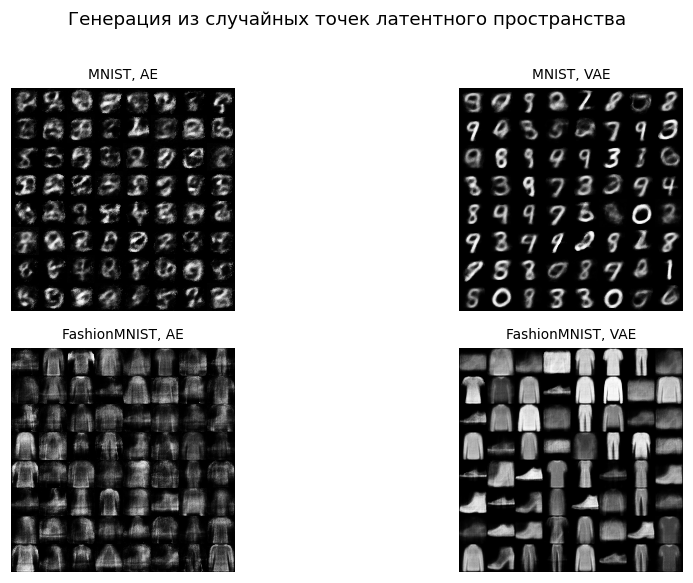

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.2))
for i, ds in enumerate(['MNIST', 'FashionMNIST']):
    for j, m in enumerate(['AE', 'VAE']):
        model = models_final[(ds, m)]
        model.eval()
        with torch.no_grad():
            imgs = model.sample(64).cpu().numpy().reshape(-1, 28, 28)
        # 64 изображения выкладываются в таблицу 8 на 8
        canvas = np.vstack([np.hstack([imgs[r * 8 + c] for c in range(8)])
                            for r in range(8)])
        axes[i, j].imshow(canvas, cmap='gray')
        axes[i, j].set_title(f'{ds}, {m}', fontsize=9)
        axes[i, j].axis('off')
fig.suptitle('Генерация из случайных точек латентного пространства', y=1.01)
plt.tight_layout()
plt.show()

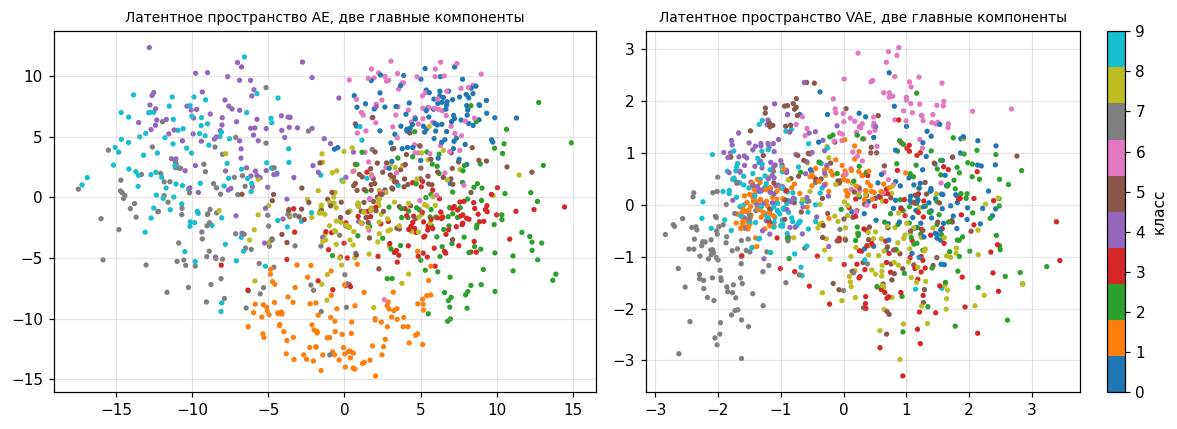

стандартное отклонение координат латента:
  AE:  1.771
  VAE: 0.125 (у N(0,1) было бы 1.000)


In [16]:
model = models_final[('MNIST', 'VAE')]
Xb = DATA['MNIST'][1]
model.eval()
with torch.no_grad():
    x = torch.tensor(Xb.reshape(len(Xb), -1)).to(DEVICE)
    z_vae = model.mu(model.encoder(x)).cpu().numpy()
    z_ae = models_final[('MNIST', 'AE')].encoder(x).cpu().numpy()

from sklearn.decomposition import PCA
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (z, name) in zip(axes, [(z_ae, 'AE'), (z_vae, 'VAE')]):
    p = PCA(2).fit_transform(z)  # латент сжимается до двух координат ради картинки
    sc = ax.scatter(p[:, 0], p[:, 1], c=DATA['MNIST'][2], cmap='tab10', s=6)
    ax.set_title(f'Латентное пространство {name}, две главные компоненты', fontsize=9)
    ax.grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='класс')
plt.tight_layout()
plt.show()

print('стандартное отклонение координат латента:')
print(f'  AE:  {z_ae.std(0).mean():.3f}')
print(f'  VAE: {z_vae.std(0).mean():.3f} (у N(0,1) было бы 1.000)')